# 06_Gradient_Descent_For_Logistic_Regression

This topic connects everything you've learned so far.

You already know:

* Logistic Regression Model
* Sigmoid Function
* Decision Boundary
* Cross-Entropy Cost Function

Now we'll learn **how the model actually learns**.

---

# 1. Theory

The goal of Logistic Regression is:

> Find the values of (w) and (b) that minimize the cost function.

Mathematically,

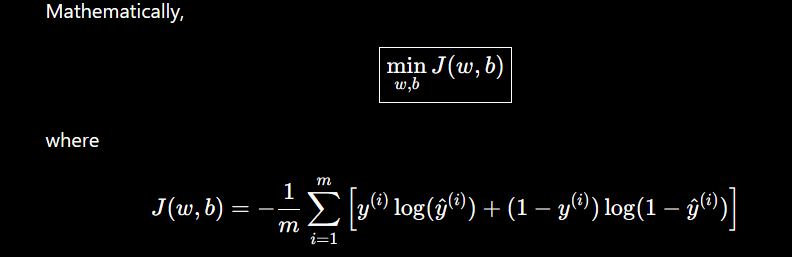

Gradient Descent is simply an optimization algorithm that solves this minimization problem.

---

# 2. Intuition

Suppose your current model predicts

| Actual | Prediction |
| ------ | ---------- |
| 1      | 0.20       |
| 0      | 0.80       |
| 1      | 0.30       |

The cost is large.

Gradient Descent asks:

> **"If I slightly change (w) and (b), will the cost increase or decrease?"**

The answer comes from the gradient.

---

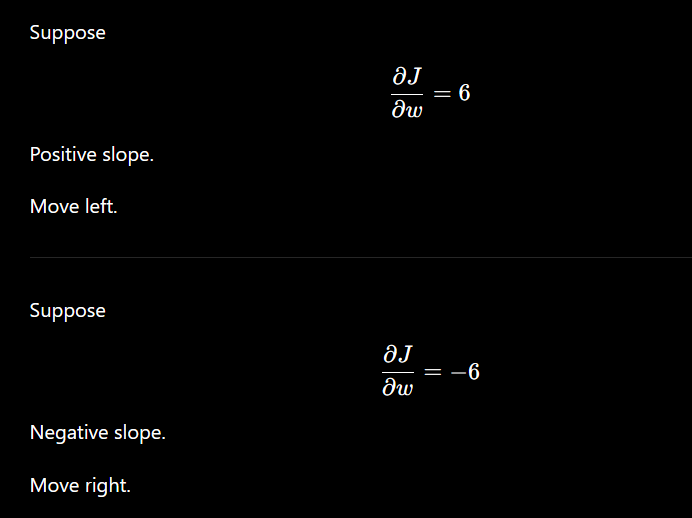

---

Nothing new here.

Exactly the same idea as Linear Regression.

The only thing that changes is how the gradient is computed.

---

# 3. Mathematics

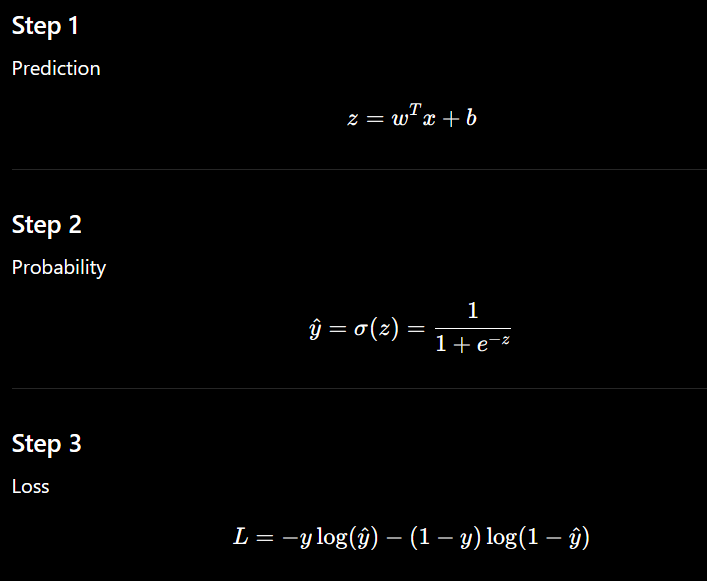

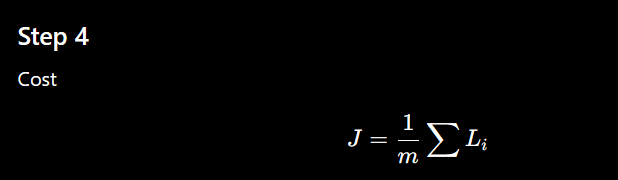

---

Now we differentiate.

---

## Chain Rule

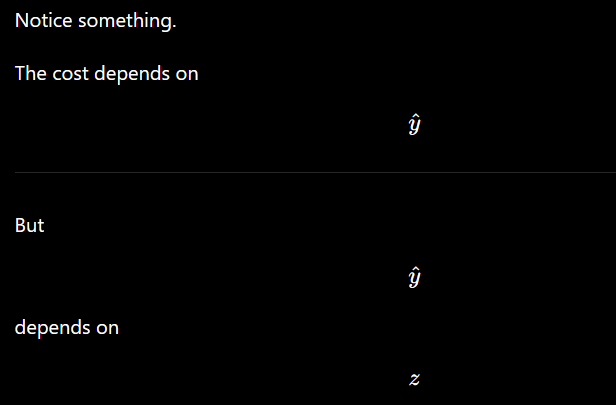

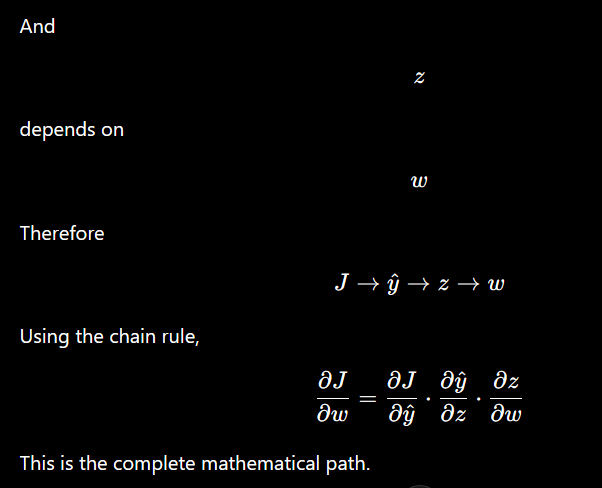

---

## Amazing Simplification

This is one of the most beautiful results in Machine Learning.

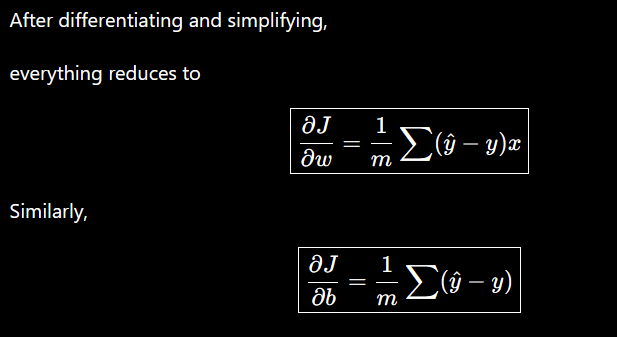

---

## Compare with Linear Regression

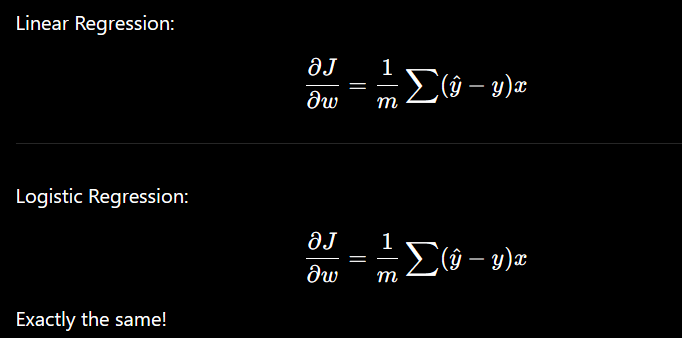

---

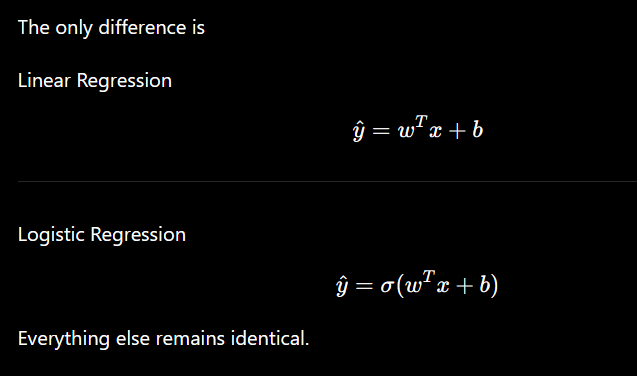

---

# Gradient Descent Update

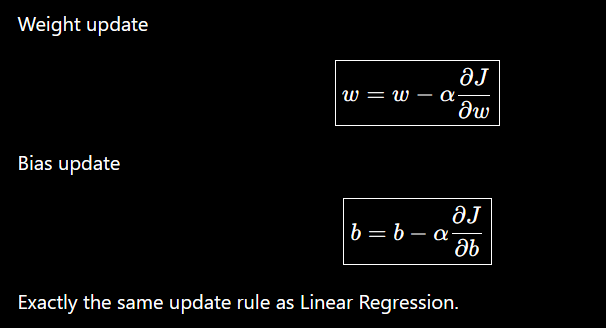

---

# Why Does It Work?

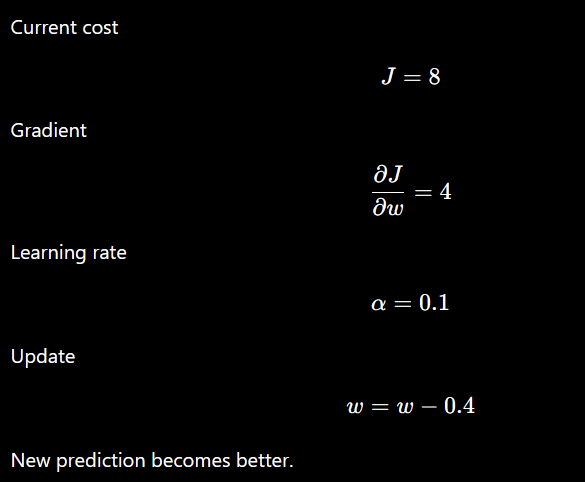

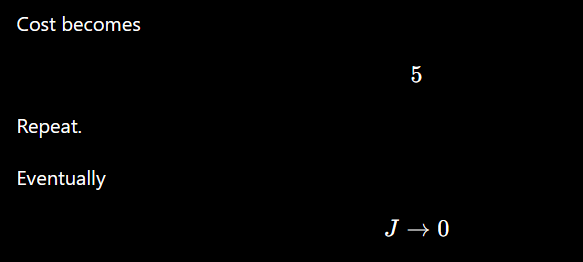

---

# Entire Learning Pipeline

```text
Training Data
      │
      ▼
Current w,b
      │
      ▼
Linear Score
z = wᵀx+b
      │
      ▼
Sigmoid
      │
      ▼
Prediction
      │
      ▼
Cross Entropy Loss
      │
      ▼
Average Loss = Cost
      │
      ▼
Gradient
      │
      ▼
Update w,b
      │
      ▼
Repeat
```

---

# Python Implementation

```python
import numpy as np

def sigmoid(z):
    return 1/(1+np.exp(-z))

X = np.array([[1],[2],[3],[4]])

y = np.array([0,0,1,1])

w = np.array([0.5])

b = -1
```

Prediction

```python
z = X @ w + b

y_hat = sigmoid(z)
```

Gradient

```python
dw = np.mean((y_hat-y.reshape(-1,1))*X)

db = np.mean(y_hat-y.reshape(-1,1))
```

Update

```python
learning_rate = 0.1

w = w-learning_rate*dw

b = b-learning_rate*db
```

---

# ML Use Case

Suppose

Initial prediction

```text
Spam Probability = 0.10
```

Actual

```text
Spam
```

Large loss.

Gradient changes

**`w,b`**

Next prediction

```text
Spam Probability = 0.40
```

Next iteration

```text
Spam Probability = 0.82
```

Eventually

```text
Spam Probability = 0.98
```

---

# Why is this mathematically elegant?

You might expect the gradient to be extremely complicated because:

* the sigmoid contains an exponential,
* the cost contains logarithms.

However, when you differentiate the cross-entropy cost with respect to the parameters, the logarithm and sigmoid terms simplify remarkably through the chain rule.

The final gradient becomes:

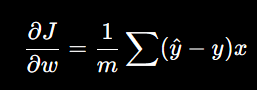

This simplicity is **not a coincidence**. Cross-Entropy and the Sigmoid are designed to work together.

---

# Where did Cross-Entropy come from?

One question still remains unanswered:

> **Why exactly is the cost function**
>
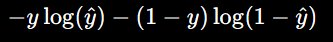
>
> **and not something else?**

The answer is **Maximum Likelihood Estimation (MLE)**.

Logistic Regression is **not** invented by choosing a convenient loss function. Instead:

1. We assume the labels follow a **Bernoulli distribution**.
2. We write the **likelihood** of observing the training data.
3. We maximize that likelihood.
4. Taking the **negative log** of the likelihood gives us the Cross-Entropy Cost Function.

This derivation explains why logarithms appear naturally and why Cross-Entropy is the mathematically correct objective for Logistic Regression.

---

## Key Takeaways

* Gradient Descent is the same optimization algorithm you learned for Linear Regression.
* The model now predicts probabilities using the sigmoid function.
* The cost function is Cross-Entropy instead of MSE.

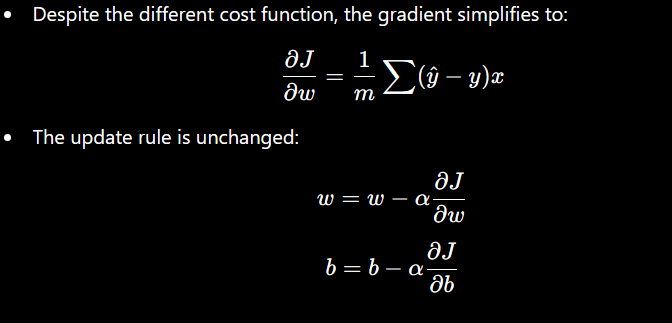

---

### One important correction to your roadmap

The notebook title is **"Gradient Descent for Logistic Regression"**, but to fully understand **why** the cost function has its particular form, I recommend adding one small subsection in this notebook:

> **Maximum Likelihood Estimation (MLE) – Derivation of Cross-Entropy Loss**

Andrew Ng introduces this idea because it explains the mathematics behind Logistic Regression, rather than treating the cost function as something to memorize. Understanding MLE now will also make probabilistic models and many future ML algorithms much easier to learn.
